---
# 9. Exercises

## Exercise 1: Poisson GLM with Identity Link

1. Generate data with the following parameters:
   - $Y \sim \text{Poi}(\mu_i)$, where $\mu_i = \beta_0 + \beta_1 x_{i1} + \beta_2 x_{i2}$, i.e., identity link: $g(\mu_i) = \mu_i = x_i^T \beta = \eta_i$
   - $X_{i1} \sim N(50, 10)$
   - $X_{i2} \sim U(10, 60)$
   - $X_{i3} \sim \text{Ber}(0.45)$ (noise variable)
   - $n = 40$

2. Fit the saturated, null, "full" (with all 3 predictors), and "best" models.

3. For each model, compute:
   - Fitted values $\hat{\mu}_i$
   - Deviance $D$
   - Pearson $X^2$

4. Compare the "full" model with the "best" model using:
   - Wald test
   - LRT (deviance difference)
   - Score (Rao) test

## Exercise 2: Monte Carlo Verification

Generate 100 datasets for $n \in \{20, 40, 60, 80, 100\}$ and:
1. Plot $(\hat{\beta}_i - \beta_i)$ vs. $n$ -- verify convergence
2. For each dataset, compute the Wald, LRT, and Score statistics for $H_0: \beta_1 = 0$
3. Make QQ-plots of the test statistics against $\chi^2(1)$ -- verify the asymptotic distribution


In [30]:
# Import
import numpy as np
from scipy.stats import chi2
import statsmodels.api as sm
import matplotlib.pyplot as plt
import pandas as pd

## Exercise 1

### 1) Generování dat

In [31]:
np.random.seed(42)
n = 40

# Kovariáty
X1 = np.random.normal(loc=50, scale=10, size=n) # X1 ~ N(50, 10)
X2 = np.random.uniform(low=10, high=60, size=n) # X2 ~ U(10, 60)
X3 = np.random.binomial(n=1, p=0.45, size=n) # X3 ~ Bernoulli(0.45)

beta0 = 5.0
beta1 = 0.5
beta2 = 1.6

# Parametry Beta
beta_true = np.array([beta0, beta1, beta2])

# Matice X
X_true = np.column_stack([np.ones(n), X1, X2])

# Střední hodnota (spojovací funkce = identita)
mu_true = X_true @ beta_true

print(f"Rozsah mu_true: [{mu_true.min():.2f}, {mu_true.max():.2f}]")
print(f"Všechna mu_i > 0: {(mu_true > 0).all()}")

# Vysvětlovaná proměnná Y
Y = np.random.poisson(lam=mu_true)

# DataFrame
d = pd.DataFrame({'Y': Y, 'X1': X1, 'X2': X2, 'X3': X3})
print(f"\nTvar dat: {d.shape}")
d.head(8)

Rozsah mu_true: [45.80, 126.05]
Všechna mu_i > 0: True

Tvar dat: (40, 4)


,Y,X1,X2,X3
0,123,54.967142,58.479231,0
1,93,48.617357,48.756641,1
2,148,56.476885,56.974947,1
3,126,65.230299,54.741368,1
4,89,47.658466,39.894999,1
5,148,47.658630,56.093712,0
6,61,65.792128,14.424625,0
7,60,57.674347,19.799143,0


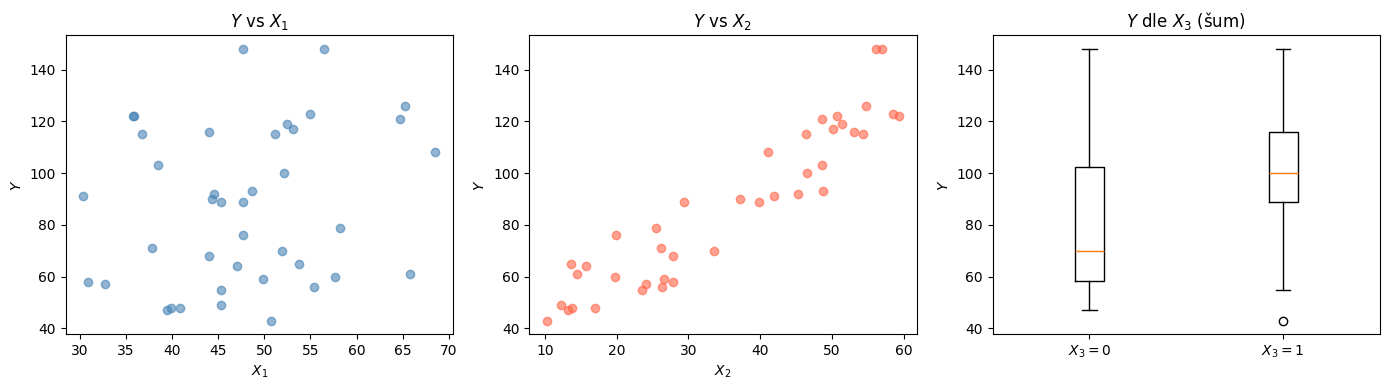

In [32]:
# Vizualizace vygenerovaného datasetu
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].scatter(X1, Y, alpha=0.6, color='steelblue')
axes[0].set_xlabel('$X_1$')
axes[0].set_ylabel('$Y$')
axes[0].set_title('$Y$ vs $X_1$')

axes[1].scatter(X2, Y, alpha=0.6, color='tomato')
axes[1].set_xlabel('$X_2$')
axes[1].set_ylabel('$Y$')
axes[1].set_title('$Y$ vs $X_2$')

axes[2].boxplot([Y[X3 == 0], Y[X3 == 1]], tick_labels=['$X_3 = 0$', '$X_3 = 1$'])
axes[2].set_ylabel('$Y$')
axes[2].set_title('$Y$ dle $X_3$ (šum)')

plt.tight_layout()
plt.show()

## 2) Fitování modelů



Fituji 4 modely:

| Model | Prediktory | Počet parametrů |
|---|---|---|
| **Saturovaný** | $n$ dummy proměnných | $p = n = 40$ |
| **Nulový** | jen intercept | $p = 1$ |
| **Plný** | $X_1, X_2, X_3$ | $p = 4$ |
| **Nejlepší** | $X_1, X_2$ | $p = 3$ |

Poznámka: volba spojovací funkce jako identity je trochu riskantní, protože IRLS může při řešení rovnice sklouznout k $\mu_i < 0$. V mém setupu nebyl s počátečním nastavením parametrů na 0 problém, ale pokud by algoritmus selhával z tohoto důvodu (pro jistotu kontroluji), lze mu předat počáteční $\beta_i$ blíže ke správným hodnotám.

In [33]:
identity_link = sm.families.links.Identity()
poisson_identity = sm.families.Poisson(link=identity_link)

# Saturovaný model
X_sat = np.eye(n) # Vytvoří identity matrix
model_sat = sm.GLM(Y, X_sat, family=poisson_identity).fit(start_params=Y.astype(float))

# Nulový model
X_null = np.ones((n, 1))
model_null = sm.GLM(Y, X_null, family=poisson_identity).fit()

# Plný model: intercept + X1 + X2 +X3
X_full = np.column_stack([np.ones(n), X1, X2, X3])
model_full = sm.GLM(Y, X_full, family=poisson_identity).fit(
    start_params=[Y.mean(), 0.0, 0.0, 0.0]
)

# Nejlepší model: intercept + X1 + X2 (bez šumu -> X3)
X_best = np.column_stack([np.ones(n), X1, X2])
model_best = sm.GLM(Y, X_best, family=poisson_identity).fit(
    start_params=[Y.mean(), 0.0, 0.0]
)

model_info = {
    'Saturovaný': model_sat,
    'Nulový': model_null,
    'Plný': model_full,
    'Nejlepší': model_best,
}

pd.DataFrame([
    {'Model': name, 'Parametrů': int(m.df_model + 1), 'Konvergoval': m.converged}
    for name, m in model_info.items()
]).set_index('Model')

/Users/vojtechremis/Desktop/VŠ/Master studies/4. semestr/ZLMA/Labs/.venv/lib/python3.12/site-packages/statsmodels/regression/_tools.py:121: RuntimeWarning: divide by zero encountered in scalar divide
  scale = np.dot(wresid, wresid) / df_resid
/Users/vojtechremis/Desktop/VŠ/Master studies/4. semestr/ZLMA/Labs/.venv/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)


,Parametrů,Konvergoval
Model,,
Saturovaný,40,True
Nulový,1,True
Plný,4,True
Nejlepší,3,True


### 3) Porovnávání modelů

In [34]:
def pearson_x2(Y, mu_hat):
    """
        Pearsonova chi-kvadrát statistika pro Poisson: sum((y - mu)^2 / mu)
    """
    return np.sum((Y - mu_hat)**2 / mu_hat)

def poisson_deviance(Y, mu_hat):
    """
        Deviace pro Y ~ Poisson
    """
    mask = Y > 0
    D = 2 * np.sum(Y[mask] * np.log(Y[mask] / mu_hat[mask]) - (Y[mask] - mu_hat[mask]))
    D += 2 * np.sum(mu_hat[~mask])
    return D

models = {
    'Saturovaný': model_sat,
    'Nulový': model_null,
    'Plný': model_full,
    'Nejlepší': model_best,
}

rows = []
for name, m in models.items():
    mu_hat = m.predict()
    rows.append({
        'Model':      name,
        'Deviace D':  round(poisson_deviance(Y, mu_hat), 4),
        'Pearson X^2': round(pearson_x2(Y, mu_hat), 4),
        'mu_hat min': round(mu_hat.min(), 2),
        'mu_hat max': round(mu_hat.max(), 2),
    })

df_results = pd.DataFrame(rows).set_index('Model')
df_results

,Deviace D,Pearson X^2,mu_hat min,mu_hat max
Model,,,,
Saturovaný,0.0000,0.0000,43.00,148.00
Nulový,405.7640,404.4697,87.03,87.03
Plný,41.2182,40.9275,42.18,132.88
Nejlepší,42.7685,42.7570,45.16,130.19


### 4) Porovnání plného a nejlepšího modelu: Wald, LRT, Score

Testuji $H_0: \beta_3 = 0$ (tj. $X_3$ nemá vliv) vs. $H_1: \beta_3 \neq 0$.

In [35]:
# Waldův test
# Y ~ Poisson => parametr \phi je známý
def wald(model, i, return_statistics=False):
    """Wald test - pro i-tý parametr."""
    beta_hat_i = model.params[i]
    se_i = np.sqrt(model.cov_params()[i, i])
    Z_wald = beta_hat_i / se_i
    W_wald = Z_wald**2

    if return_statistics:
        return W_wald
    else:
        p_wald = chi2.sf(W_wald, df=1)
        return W_wald, p_wald

W_wald, p_wald = wald(model_full, 3)

# LRT
def lrt(model_full, model_red, return_statistics=False):
    D_full = model_full.deviance
    D_red = model_red.deviance
    T_lrt = D_red - D_full

    if return_statistics:
        return T_lrt
    else:
        p_lrt = chi2.sf(T_lrt, df=1)
        return T_lrt, p_lrt

T_lrt, p_lrt = lrt(model_full, model_best)

# Score (Rao)
def rao_score(model_red, X_full, test_idx, Y, return_statistics=False):
    mu0 = model_red.predict()
    Xi = X_full[:, test_idx]
    U_i = np.sum(Xi * (Y - mu0) / mu0) 
    W = np.diag(1.0 / mu0)
    I_full = X_full.T @ W @ X_full
    I_full_inv = np.linalg.inv(I_full)
    S_score = (U_i**2) * I_full_inv[test_idx, test_idx]

    if return_statistics:
        return S_score
    else:
        p_score = chi2.sf(S_score, df=1)
        return S_score, p_score

S_score, p_score = rao_score(model_best, X_full, 3, Y)

# Summary tabulka
pd.DataFrame([
    {'Test': 'Wald', 'Statistika': round(W_wald, 4), 'df': 1, 'p-value': round(p_wald, 6)},
    {'Test': 'LRT', 'Statistika': round(T_lrt, 4), 'df': 1, 'p-value': round(p_lrt, 6)},
    {'Test': 'Score', 'Statistika': round(S_score, 4), 'df': 1, 'p-value': round(p_score, 6)},
]).set_index('Test')

,Statistika,df,p-value
Test,,,
Wald,1.5878,1,0.207645
LRT,1.5503,1,0.213097
Score,1.5225,1,0.217239


Poznámka: nezamítáme $H_0$ na hladině $\alpha = 0.05$, tedy $X_3$ nemá vliv. Což jsme předpokládali, protože jsme data takto vygenerovali.

## Exercise 2
Testuji $H_0: \beta_1 = 0$ vs. $H_1: \beta_1 \neq 0$.

In [36]:
import warnings
warnings.filterwarnings("ignore", message="The Identity link function does not respect the domain")

np.random.seed(42)
n_rep   = 100
n_sizes = [20, 40, 60, 80, 100]

# Výsledky
betas_hat = {n: [] for n in n_sizes}
test_stats = {n: {'Wald': [], 'LRT': [], 'Score': []} for n in n_sizes}

for n in n_sizes:
    for _ in range(n_rep):
        x1 = np.random.normal(50, 10, n)
        x2 = np.random.uniform(10, 60, n)

        # 1) Konvergence: generování za neplatnosti nulté hypotézy (B1 != 0)
        mu_true_mc = beta0 + beta1 * x1 + beta2 * x2
        y_true = np.random.poisson(mu_true_mc)
        X_full_mc = np.column_stack([np.ones(n), x1, x2])

        m = sm.GLM(y_true, X_full_mc, family=poisson_identity).fit(
            start_params=[y_true.mean(), 0.0, 0.0]
        )
        if m.converged:
            betas_hat[n].append(m.params)

        # 2) Test statistiky: generování pod H0 (B1 = 0)
        mu_h0 = beta0 + beta2 * x2 # beta1 = 0
        y_h0 = np.random.poisson(mu_h0)
        X_red_mc = np.column_stack([np.ones(n), x2])

        m_full = sm.GLM(y_h0, X_full_mc, family=poisson_identity).fit(
            start_params=[y_h0.mean(), 0.0, 0.0]
        )
        m_red = sm.GLM(y_h0, X_red_mc, family=poisson_identity).fit(
            start_params=[y_h0.mean(), 0.0]
        )
        if not (m_full.converged and m_red.converged):
            continue

        # Wald
        W = wald(m_full, 1, return_statistics=True)

        # LRT
        T = lrt(m_full, m_red, return_statistics=True)

        # Score
        S = rao_score(model_red=m_red, X_full=X_full_mc, test_idx=1, Y=y_h0, return_statistics=True)

        test_stats[n]['Wald'].append(W)
        test_stats[n]['LRT'].append(T)
        test_stats[n]['Score'].append(S)

print("Počty úspěšných simulací:")
for n in n_sizes:
    nw = len(test_stats[n]['Wald'])
    nb = len(betas_hat[n])
    print(f"\tn={n:4d}: konvergence={nb}, testové statistiky={nw}")

Počty úspěšných simulací:
	n=  20: konvergence=100, testové statistiky=100
	n=  40: konvergence=100, testové statistiky=100
	n=  60: konvergence=100, testové statistiky=100
	n=  80: konvergence=100, testové statistiky=100
	n= 100: konvergence=100, testové statistiky=100


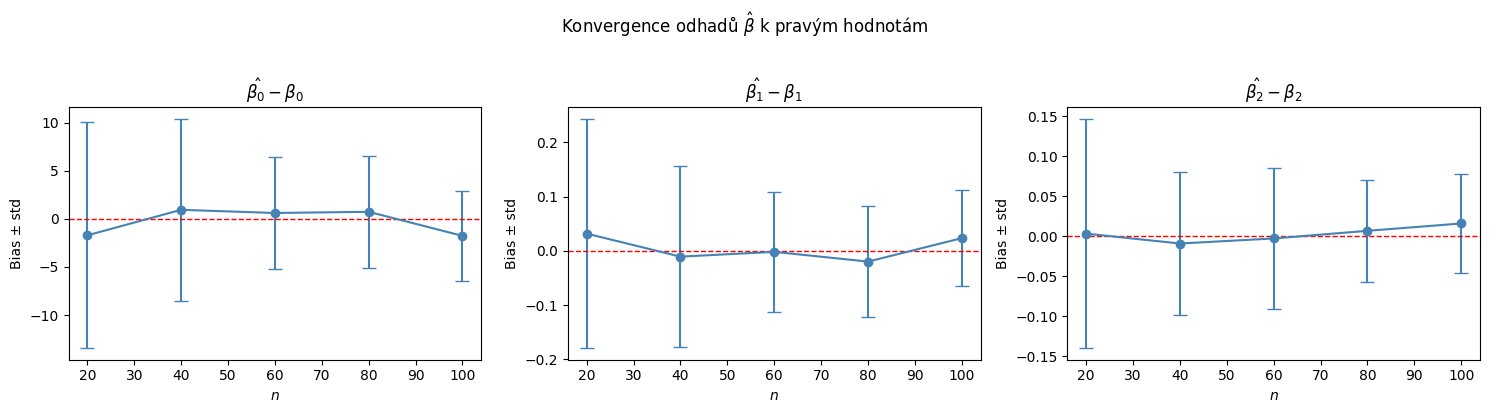

In [37]:
# Graf 1: Konvergence beta_hat -> beta_true
beta_names  = [r'\beta_0', r'\beta_1', r'\beta_2']
beta_truths = [beta0, beta1, beta2]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for j, (ax, b_name, b_true) in enumerate(zip(axes, beta_names, beta_truths)):
    means = [np.mean([b[j] for b in betas_hat[n]]) - b_true for n in n_sizes]
    stds = [np.std([b[j]  for b in betas_hat[n]]) for n in n_sizes]
    ax.errorbar(n_sizes, means, yerr=stds, fmt='o-', capsize=5, color='steelblue')
    ax.axhline(0, color='red', linestyle='--', linewidth=1)
    ax.set_title(f'$\\hat{{{b_name}}} - {b_name}$')
    ax.set_xlabel('$n$')
    ax.set_ylabel('Bias ± std')

plt.suptitle(r"Konvergence odhadů $\hat{\beta}$ k pravým hodnotám", y=1.02)
plt.tight_layout()
plt.show()

Poznámka: Se zvyšujícím se n vidíme zmenšující se rozptyl odhadu parametrů (konzistence).

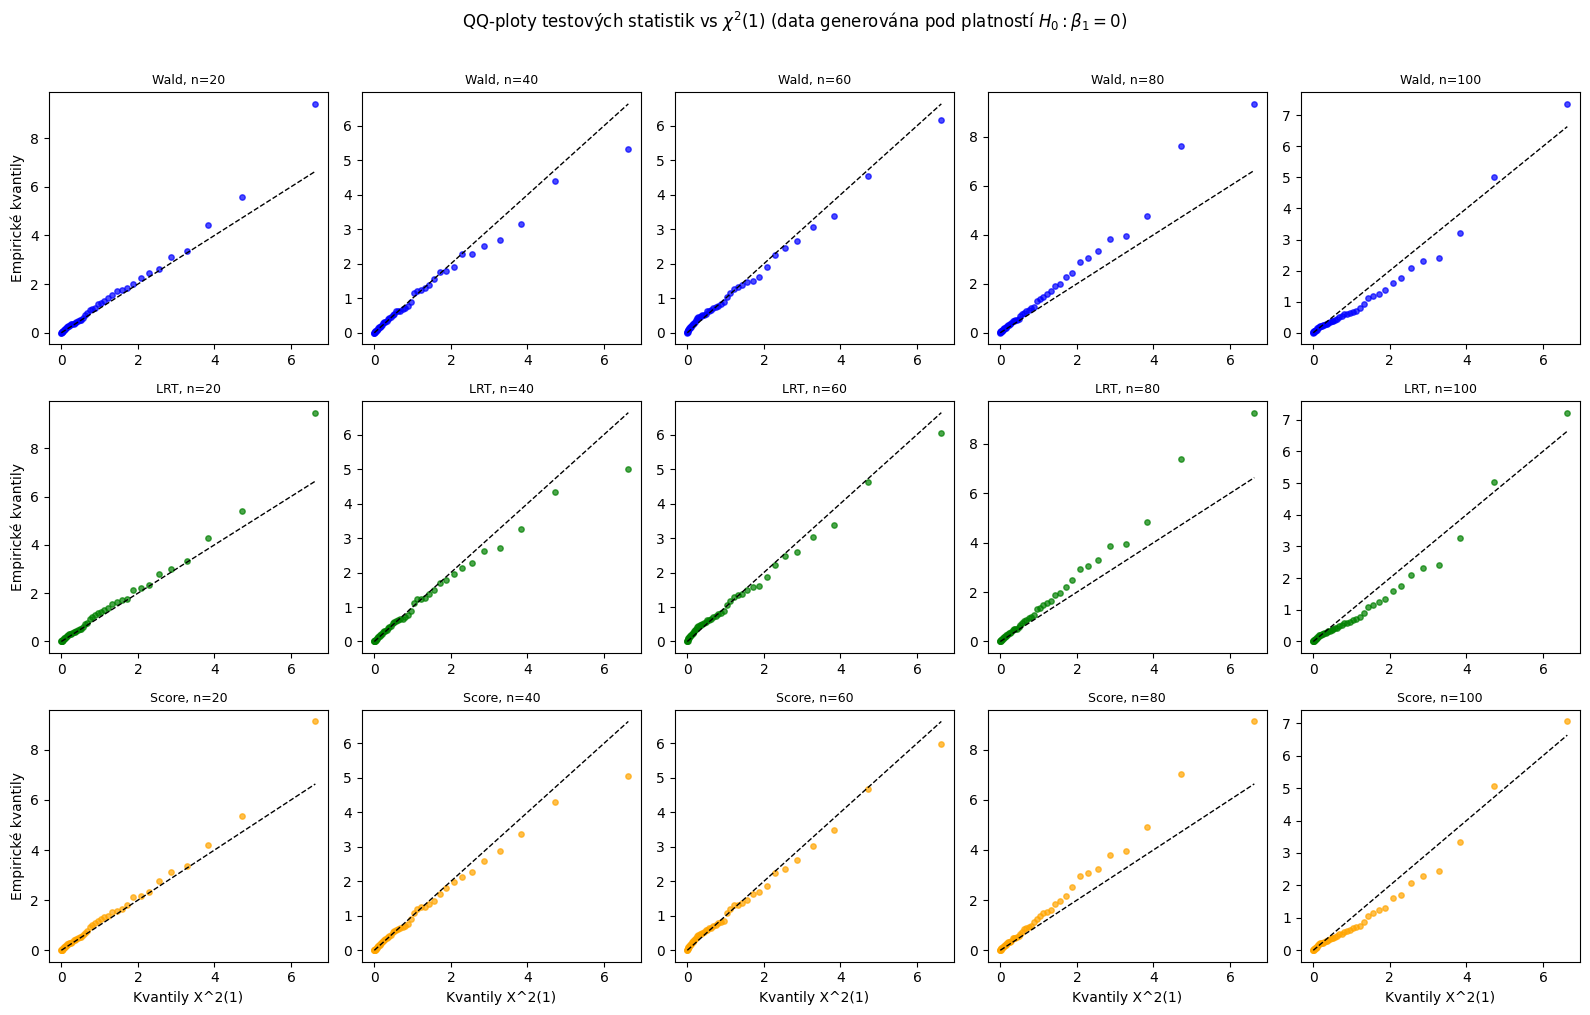

In [38]:
test_names = ['Wald', 'LRT', 'Score']
colors = ['blue', 'green', 'orange']

fig, axes = plt.subplots(3, 5, figsize=(16, 10))

# Kvantily teoretického X^2
probs = np.linspace(0.01, 0.99, 50)
chi2_quantiles = chi2.ppf(probs, df=1)

for row, (tname, color) in enumerate(zip(test_names, colors)):
    for col, n in enumerate(n_sizes):
        ax = axes[row, col]
        vals = np.array(test_stats[n][tname])

        # Empirické kvantily
        emp_quantiles = np.quantile(vals, probs)

        ax.scatter(chi2_quantiles, emp_quantiles, s=15, color=color, alpha=0.7)
        ax.plot([0, chi2_quantiles[-1]], [0, chi2_quantiles[-1]], 'k--', linewidth=1)
        ax.set_title(f'{tname}, n={n}', fontsize=9)
        if col == 0:
            ax.set_ylabel('Empirické kvantily')
        if row == 2:
            ax.set_xlabel('Kvantily X^2(1)')

plt.suptitle("QQ-ploty testových statistik vs $\\chi^2(1)$ (data generována pod platností $H_0: \\beta_1=0$)", y=1.01)
plt.tight_layout()
plt.show()